# 05 — CNN Classifier

**Scientific question:** Do cytoskeletal drugs affect nuclear morphology detectable from DAPI images alone?

**Strategy:**
- Level 1 (binary)     : DMSO vs AcDep (LatA + CytoD pooled)
- Level 2 (multi-class): DMSO, AcDep, Blebbi, CK666, Noco

Start at Level 1. Change `MODE = 'multiclass'` in Cell 1 to switch.

**Validation:** leave-one-replicate-out — hold out one full replicate as test set.
This tests generalization to a new experiment, not just new cells from the same experiment.

**Architecture:**
```
Input  [B,  1, 64, 64]
Conv1 + BN + ReLU + MaxPool  →  [B, 16, 32, 32]
Conv2 + BN + ReLU + MaxPool  →  [B, 32, 16, 16]
Conv3 + BN + ReLU + MaxPool  →  [B, 64,  8,  8]
Flatten                      →  [B, 4096]
FC1 + ReLU + Dropout(0.5)    →  [B, 256]
FC2                          →  [B, n_classes]
```

## Cell 1 — Parameters

In [ ]:
# ── Data ──────────────────────────────────────────────────────────────────────
PATCHES_PATH = ""
OUTPUT_DIR   = ""

# ── Mode ──────────────────────────────────────────────────────────────────────
# 'binary'     → DMSO vs AcDep only (start here)
# 'multiclass' → all 5 conditions
MODE = 'binary'

# ── Validation ────────────────────────────────────────────────────────────────
# Which replicate to hold out as test set.

TEST_REPLICATE = ''

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE  = 16
N_EPOCHS    = 60
LR          = 1e-3
DROPOUT     = 0.6
RANDOM_SEED = 42

print(f"Mode           : {MODE}")
print(f"Test replicate : {TEST_REPLICATE}")
print(f"Epochs         : {N_EPOCHS}")

Mode           : binary
Test replicate : 250523
Epochs         : 60


## Cell 2 — Imports

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Device — use MPS on Apple Silicon, else CUDA, else CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"Device : {DEVICE}")

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Device : mps


## Cell 3 — Load patches and split train / test

In [87]:
# Load
data    = np.load(PATCHES_PATH, allow_pickle=True)
patches = data['patches'].astype(np.float32)
labels  = data['labels']
meta    = data['meta']

# Fix any patches with wrong axis order
print(f"Raw patches shape: {patches.shape}")
if patches.shape[1] != 1:
    patches = patches.squeeze()
    if patches.ndim == 3:
        patches = patches[:, np.newaxis, :, :]
print(f"Final shape: {patches.shape}")  # should be (N, 1, 64, 64)

# Extract replicate from meta string
replicates = np.array([m.split('/')[0] for m in meta])

print(f"Loaded {len(patches)} patches")
print(f"Classes found: {sorted(set(labels))}")

# ── Filter by mode ────────────────────────────────────────────────────────────
if MODE == 'binary':
    keep_mask = np.isin(labels, ['DMSO', 'AcDep'])
    patches    = patches[keep_mask]
    labels     = labels[keep_mask]
    replicates = replicates[keep_mask]
    meta       = meta[keep_mask]
    print(f"Binary mode → kept {keep_mask.sum()} patches (DMSO + AcDep)")
else:
    print(f"Multi-class mode → using all {len(patches)} patches")

# ── Encode labels to integers ─────────────────────────────────────────────────
le      = LabelEncoder()
y       = le.fit_transform(labels)   # e.g. AcDep=0, DMSO=1
classes = le.classes_
n_classes = len(classes)

print(f"\nLabel encoding:")
for i, cls in enumerate(classes):
    print(f"  {i} → {cls}  (n={( y == i).sum()})")

# ── Train / test split by replicate ───────────────────────────────────────────
test_mask  = replicates == TEST_REPLICATE
train_mask = ~test_mask

X_train, y_train = patches[train_mask], y[train_mask]
X_test,  y_test  = patches[test_mask],  y[test_mask]

print(f"\nTrain : {len(X_train)} patches  (replicates: {sorted(set(replicates[train_mask]))})")
print(f"Test  : {len(X_test)}  patches  (replicate:  {TEST_REPLICATE})")
print(f"\nTrain class distribution:")
for i, cls in enumerate(classes):
    print(f"  {cls}: {(y_train == i).sum()}")

Raw patches shape: (356, 1, 64, 64)
Final shape: (356, 1, 64, 64)
Loaded 356 patches
Classes found: [np.str_('AcDep'), np.str_('Blebbi'), np.str_('CK666'), np.str_('DMSO'), np.str_('Noco')]
Binary mode → kept 250 patches (DMSO + AcDep)

Label encoding:
  0 → AcDep  (n=148)
  1 → DMSO  (n=102)

Train : 235 patches  (replicates: [np.str_('241017'), np.str_('241018MaxProj'), np.str_('241110MaxProj'), np.str_('250416'), np.str_('251002')])
Test  : 15  patches  (replicate:  250523)

Train class distribution:
  AcDep: 148
  DMSO: 87


## Cell 4 — Dataset with augmentation

In [88]:
class NucleusDataset(Dataset):
    """
    PyTorch Dataset for nucleus patches.

    Augmentation (training only):
    - Random horizontal + vertical flip  → orientation invariance
    - Random 90° rotation                → orientation invariance
    - Random rotation ±15°               → small angle invariance
    - Random intensity jitter ±10%       → staining variability

    Why augment?
    With only ~150 training patches, the network would memorize the
    training set within a few epochs without augmentation (overfitting).
    Augmentation artificially expands the effective dataset by showing
    the same nucleus in different orientations and intensities.
    Nuclear morphology features (shape, chromatin texture) are rotation-
    and flip-invariant by biology, so these augmentations are valid.
    """

    def __init__(self, patches, labels, augment=False):
        self.patches = torch.tensor(patches, dtype=torch.float32)  # (N, 1, 64, 64)
        self.labels  = torch.tensor(labels,  dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        x = self.patches[idx]   # (1, 64, 64)
        y = self.labels[idx]

        if self.augment:
            # Random horizontal flip
            if torch.rand(1) > 0.5:
                x = TF.hflip(x)
            # Random vertical flip
            if torch.rand(1) > 0.5:
                x = TF.vflip(x)
            # Random 90° rotation (0, 90, 180, 270)
            k = torch.randint(0, 4, (1,)).item()
            x = torch.rot90(x, k, dims=[1, 2])
            # Random small rotation ±15°
            angle = (torch.rand(1).item() - 0.5) * 30  # [-15, +15]
            x = TF.rotate(x, angle)
            # Random intensity jitter ±10%
            factor = 1.0 + (torch.rand(1).item() - 0.5) * 0.2
            x = torch.clamp(x * factor, 0.0, 1.0)

        return x, y


train_dataset = NucleusDataset(X_train, y_train, augment=True)
test_dataset  = NucleusDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train dataset : {len(train_dataset)} patches (augmented)")
print(f"Test dataset  : {len(test_dataset)}  patches (no augmentation)")
print(f"Train batches : {len(train_loader)}")

Train dataset : 235 patches (augmented)
Test dataset  : 15  patches (no augmentation)
Train batches : 14


## Cell 5 — CNN architecture

In [89]:
class NucleusCNN(nn.Module):
    """
    Small CNN for nucleus patch classification.

    Design choices:
    - 3 convolutional blocks only → appropriate for small dataset (225 patches)
    - BatchNorm after each conv   → stabilizes training, reduces sensitivity to LR
    - MaxPool after each block    → progressively reduces spatial resolution,
                                    forces learning of abstract features
    - Dropout(0.5) before FC      → strong regularization to prevent overfitting

    Feature map progression:
        Input          : (B,  1, 64, 64)
        After block 1  : (B, 16, 32, 32)  ← detects edges, simple shapes
        After block 2  : (B, 32, 16, 16)  ← detects textures, local patterns
        After block 3  : (B, 64,  8,  8)  ← detects complex nuclear shapes
        After flatten  : (B, 4096)
        After FC1      : (B, 256)
        Output         : (B, n_classes)   ← raw logits (no softmax — CrossEntropyLoss handles it)
    """

    def __init__(self, n_classes, dropout=0.5):
        super().__init__()

        # Convolutional blocks
        # Each block: Conv2d → BatchNorm2d → ReLU → MaxPool2d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (B, 1, 64, 64) → (B, 16, 64, 64)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → (B, 16, 32, 32)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # → (B, 32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → (B, 32, 16, 16)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → (B, 64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)                              # → (B, 64,  8,  8)
        )

        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Flatten(),                                # → (B, 64*8*8) = (B, 4096)
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes)                   # → (B, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


model = NucleusCNN(n_classes=n_classes, dropout=DROPOUT).to(DEVICE)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(model)

Model parameters: 1,072,866
NucleusCNN(
  (block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear

## Cell 6 — Loss function, optimizer, class weights

In [90]:
# Class weights — inverse frequency weighting
# Penalizes misclassification of minority classes more heavily.
# Without this, the network learns to predict the majority class most of the time.
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * n_classes  # normalize
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class weights (higher = penalized more):")
for i, cls in enumerate(classes):
    print(f"  {cls}: {class_weights[i]:.3f}  (n_train={class_counts[i]})")

# CrossEntropyLoss — combines LogSoftmax + NLLLoss in one step
# Expects raw logits from the network (no softmax needed in forward())
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Adam optimizer — adaptive learning rate, works well out of the box
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# ReduceLROnPlateau — halves the learning rate if validation loss stops improving
# patience=10 → waits 10 epochs before reducing
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

print(f"\nOptimizer : Adam (lr={LR})")
print(f"Scheduler : ReduceLROnPlateau (patience=10, factor=0.5)")

Class weights (higher = penalized more):
  AcDep: 0.740  (n_train=148)
  DMSO: 1.260  (n_train=87)

Optimizer : Adam (lr=0.001)
Scheduler : ReduceLROnPlateau (patience=10, factor=0.5)


## Cell 7 — Training loop

In [91]:
train_losses = []
test_losses  = []
train_accs   = []
test_accs    = []

best_test_acc  = 0.0
best_model_path = Path(OUTPUT_DIR) / f"best_model_{MODE}.pt"

print(f"Training for {N_EPOCHS} epochs on {DEVICE}...\n")

for epoch in range(1, N_EPOCHS + 1):

    # ── Training phase ────────────────────────────────────────────────────────
    model.train()
    epoch_loss, epoch_correct, epoch_total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(X_batch)          # forward pass
        loss   = criterion(logits, y_batch)  # compute loss
        loss.backward()                  # backpropagation
        optimizer.step()                 # update weights

        epoch_loss    += loss.item() * len(y_batch)
        preds          = logits.argmax(dim=1)
        epoch_correct += (preds == y_batch).sum().item()
        epoch_total   += len(y_batch)

    train_loss = epoch_loss / epoch_total
    train_acc  = epoch_correct / epoch_total

    # ── Evaluation phase ──────────────────────────────────────────────────────
    model.eval()
    eval_loss, eval_correct, eval_total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            eval_loss    += loss.item() * len(y_batch)
            preds         = logits.argmax(dim=1)
            eval_correct += (preds == y_batch).sum().item()
            eval_total   += len(y_batch)

    test_loss = eval_loss / eval_total
    test_acc  = eval_correct / eval_total

    scheduler.step(test_loss)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), best_model_path)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | "
              f"Train loss={train_loss:.3f} acc={train_acc:.2%} | "
              f"Test  loss={test_loss:.3f} acc={test_acc:.2%}")

print(f"\nBest test accuracy: {best_test_acc:.2%}")
print(f"Best model saved → {best_model_path}")

Training for 60 epochs on mps...

Epoch   1/60 | Train loss=1.748 acc=50.00% | Test  loss=0.845 acc=0.00%
Epoch  10/60 | Train loss=0.692 acc=51.79% | Test  loss=0.787 acc=20.00%
Epoch  20/60 | Train loss=0.660 acc=58.48% | Test  loss=0.702 acc=53.33%
Epoch  30/60 | Train loss=0.642 acc=60.71% | Test  loss=0.710 acc=53.33%
Epoch  40/60 | Train loss=0.609 acc=66.96% | Test  loss=0.740 acc=46.67%
Epoch  50/60 | Train loss=0.612 acc=66.96% | Test  loss=0.809 acc=40.00%
Epoch  60/60 | Train loss=0.600 acc=68.75% | Test  loss=0.750 acc=46.67%

Best test accuracy: 86.67%
Best model saved → /Users/giuliaam/Desktop/Newlife/ML_Project/CompoundsData/OutputCP/CNN/best_model_binary.pt


## Cell 8 — Training curves

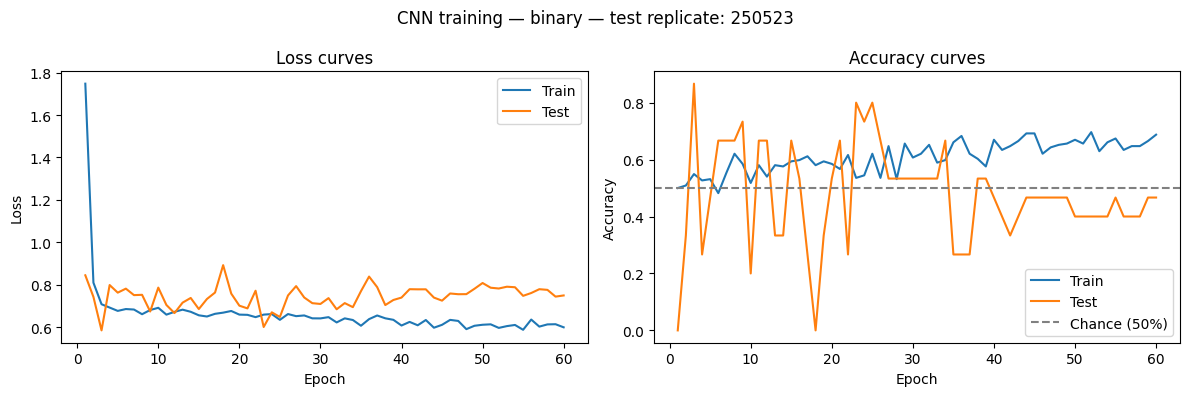

Final train acc : 68.75%
Final test acc  : 46.67%
Best test acc   : 86.67%
Train-test gap  : 22.08%
⚠️  Large train-test gap → model is overfitting.
   → Try: more augmentation, higher dropout, fewer epochs.


In [92]:
epochs = range(1, N_EPOCHS + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(epochs, train_losses, label='Train')
ax[0].plot(epochs, test_losses,  label='Test')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].set_title('Loss curves')
ax[0].legend()

ax[1].plot(epochs, train_accs, label='Train')
ax[1].plot(epochs, test_accs,  label='Test')
ax[1].axhline(1/n_classes, color='gray', linestyle='--', label=f'Chance ({1/n_classes:.0%})')
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].set_title('Accuracy curves')
ax[1].legend()

plt.suptitle(f"CNN training — {MODE} — test replicate: {TEST_REPLICATE}")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves_{MODE}.png", dpi=150, bbox_inches='tight')
plt.show()

# Overfitting diagnosis
gap = np.array(train_accs) - np.array(test_accs)
print(f"Final train acc : {train_accs[-1]:.2%}")
print(f"Final test acc  : {test_accs[-1]:.2%}")
print(f"Best test acc   : {best_test_acc:.2%}")
print(f"Train-test gap  : {gap[-1]:.2%}")
if gap[-1] > 0.20:
    print("⚠️  Large train-test gap → model is overfitting.")
    print("   → Try: more augmentation, higher dropout, fewer epochs.")

## Cell 9 — Confusion matrix and classification report

Classification report (test set):
              precision    recall  f1-score   support

       AcDep       0.00      0.00      0.00         0
        DMSO       1.00      0.87      0.93        15

    accuracy                           0.87        15
   macro avg       0.50      0.43      0.46        15
weighted avg       1.00      0.87      0.93        15



/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


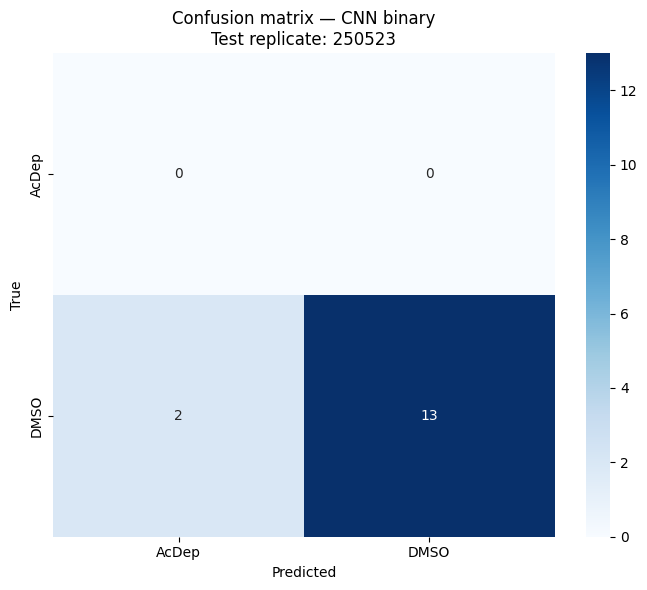

In [93]:
# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

all_preds  = []
all_probs  = []
all_true   = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1).cpu().numpy()
        preds   = logits.argmax(dim=1).cpu().numpy()

        all_preds.append(preds)
        all_probs.append(probs)
        all_true.append(y_batch.numpy())

all_preds = np.concatenate(all_preds)
all_probs = np.concatenate(all_probs)
all_true  = np.concatenate(all_true)

# Classification report
print("Classification report (test set):")
print(classification_report(all_true, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(5 + n_classes, 4 + n_classes))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes, ax=ax
)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion matrix — CNN {MODE}\nTest replicate: {TEST_REPLICATE}')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_cnn_{MODE}.png", dpi=150, bbox_inches='tight')
plt.show()

## Cell 10 — ROC curve (binary only)

/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/anaconda3/envs/unet-env/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1294: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


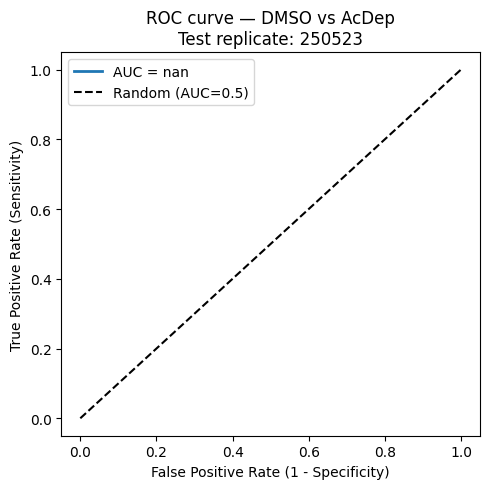

AUC-ROC: nan
AUC interpretation:
  0.5 → random chance
  0.7 → acceptable
  0.8 → good
  0.9 → excellent


In [94]:
if MODE == 'binary':
    # AcDep=0, DMSO=1 after LabelEncoder — use probability of class 1 (DMSO)
    # ROC curve shows sensitivity vs 1-specificity across all thresholds
    auc = roc_auc_score(all_true, all_probs[:, 1])
    fpr, tpr, _ = roc_curve(all_true, all_probs[:, 1])

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate (1 - Specificity)')
    ax.set_ylabel('True Positive Rate (Sensitivity)')
    ax.set_title(f'ROC curve — DMSO vs AcDep\nTest replicate: {TEST_REPLICATE}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/roc_curve_binary.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"AUC-ROC: {auc:.3f}")
    print("AUC interpretation:")
    print("  0.5 → random chance")
    print("  0.7 → acceptable")
    print("  0.8 → good")
    print("  0.9 → excellent")
else:
    print("ROC curve only computed for binary mode.")

In [96]:
AUC = [0.85, 0.685, 0.663]
res = np.mean(AUC)
res


np.float64(0.7326666666666668)